# CIFAR10 and Transfer Learning

## CIFAR10

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.utils
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import numpy as np
import os

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
train_data = dsets.CIFAR10(root='./data', 
                           train=True,
                           download=True, 
                           transform=transforms.ToTensor())

test_data  = dsets.CIFAR10(root='./data', 
                           train=False,
                           download=True, 
                           transform=transforms.ToTensor())

In [4]:
batch_size = 128

train_loader = DataLoader(train_data, 
                          batch_size=batch_size,
                          shuffle=True)

test_loader = DataLoader(test_data, 
                         batch_size=5,
                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

In [5]:
def imshow(img, title):
    img = torchvision.utils.make_grid(img, normalize=True)
    npimg = img.numpy()
    fig = plt.figure(figsize = (5, 15))
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

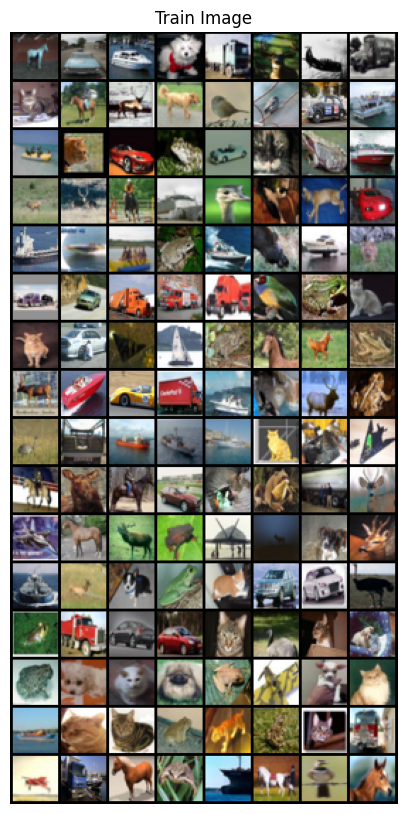

In [6]:
train_iter = iter(train_loader)
images, labels = next(train_iter)

imshow(images, "Train Image")

In [7]:
images.shape

torch.Size([128, 3, 32, 32])

## Train and Evaluate CNN

### Train CNN

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(64*5*5, 100),
            nn.ReLU(),
            nn.Linear(100, 10)              
        )
        
    def forward(self, x):
        out = self.conv_layer(x)
        out = out.view(-1, 64*5*5)
        out = self.fc_layer(out)
        
        return out
    
model = CNN().cuda()

In [9]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [10]:
num_epochs = 10

In [11]:
for epoch in range(num_epochs):

    total_batch = len(train_data) // batch_size
    
    for i, (batch_images, batch_labels) in enumerate(train_loader):
        
        x = batch_images.cuda()
        y = batch_labels.cuda()

        pre = model(x)
        cost = loss(pre, y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/10], lter [200/390], Loss: 2.2693


Epoch [2/10], lter [200/390], Loss: 2.0257


Epoch [3/10], lter [200/390], Loss: 1.9701


Epoch [4/10], lter [200/390], Loss: 1.8367


Epoch [5/10], lter [200/390], Loss: 1.7920


Epoch [6/10], lter [200/390], Loss: 1.6552


Epoch [7/10], lter [200/390], Loss: 1.5783


Epoch [8/10], lter [200/390], Loss: 1.6178


Epoch [9/10], lter [200/390], Loss: 1.4480


Epoch [10/10], lter [200/390], Loss: 1.3436


### Evalute Model

In [12]:
correct = 0
total = 0

for images, labels in test_loader:
    
    images = images.cuda()
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()
    
print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

Accuracy of test images: 46.560000 %


Predicted:    cat  ship   car  ship  frog


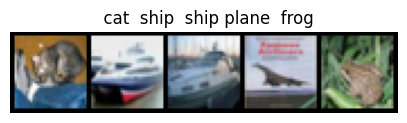

In [13]:
images, labels = next(iter(test_loader))
outputs = model(images.cuda())

_, predicted = torch.max(outputs.data, 1)
    
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(5)))

title = (' '.join('%5s' % classes[labels[j]] for j in range(5)))
imshow(images, title)

## Train and Evaluate Developed CNN

### Preprocessing Data

In [14]:
transform = transforms.Compose([
    # 데이터 증강
    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(32),
    
    # 데이터 정규화
    # Data Normalization
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# 텐서 이미지를 평균/표준편차로 정규화
# Normalize a tensor image using mean and std
# 채널별 mean=(M1..Mn), std=(S1..Sn) 가 주어졌을 때,
# Given mean=(M1..Mn) and std=(S1..Sn) for n channels,
# 이 변환은 입력 토치 텐서의 각 채널을 정규화함
# This transform normalizes each channel of the input torch tensor
# 입력 텐서를 채널별로 정규화: input[c] = (input[c] - mean[c]) / std[c]
# Normalize per channel: input[c] = (input[c] - mean[c]) / std[c]

train_data = dsets.CIFAR10(root='./data', 
                           train=True,
                           download=True, 
                           transform=transform)

test_data  = dsets.CIFAR10(root='./data', 
                           train=False,
                           download=True, 
                           transform=transform)

In [15]:
batch_size = 128

train_loader = DataLoader(train_data, 
                          batch_size=batch_size,
                          shuffle=True)

test_loader = DataLoader(test_data, 
                         batch_size=batch_size,
                         shuffle=False)

### Train CNN

In [16]:
import torch.nn.init as init

In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, 5),
            nn.BatchNorm2d(32), # Batch Nomalization
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 5),
            nn.BatchNorm2d(64), # Batch Nomalization
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 5 * 5, 100),
            nn.ReLU(),
            nn.Dropout(0.1), # Dropout
            nn.Linear(100, 10)              
        )
        
        # 가중치 초기화
        # Weight initialization
        for m in self.modules() :
            if isinstance(m, nn.Conv2d):
                # init.xavier_normal(m.weight.data)
                init.kaiming_normal_(m.weight.data)
                m.bias.data.fill_(0)      
            if isinstance(m, nn.Linear):
                # init.xavier_normal(m.weight.data)
                init.kaiming_normal_(m.weight.data)
                m.bias.data.fill_(0)                
        
    def forward(self, x):
        out = self.conv_layer(x)
        out = out.view(-1, 64*5*5)
        out = self.fc_layer(out)
        
        return out
    
model = CNN().cuda()

### Custom Weight Initialization (Revisited)

In [18]:
model.conv_layer

Sequential(
  (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [19]:
model.conv_layer[0].weight

Parameter containing:
tensor([[[[-4.6418e-02,  2.3820e-01, -6.9506e-02, -1.8084e-01, -2.1249e-01],
          [ 1.1228e-02,  4.4523e-01,  1.2858e-01, -3.3849e-02,  1.1669e-01],
          [ 1.1786e-01,  3.3951e-02, -1.5321e-01, -1.5276e-01, -3.2127e-01],
          [-7.7545e-02,  1.6905e-01,  1.1479e-01,  3.0869e-01,  1.1217e-01],
          [ 6.0326e-02,  9.8569e-02,  2.4046e-01, -2.8042e-03, -5.1680e-02]],

         [[-2.5771e-01, -3.0523e-01, -1.3134e-01,  1.0387e-01,  5.7633e-02],
          [ 2.5288e-01,  4.4247e-02,  1.9170e-02,  1.2064e-01,  1.2780e-01],
          [ 1.6139e-01, -1.1861e-01,  3.7864e-02,  1.5322e-01,  4.6236e-02],
          [ 8.5426e-02,  2.3391e-01,  1.9495e-01, -9.9287e-02, -1.0668e-01],
          [ 1.7024e-01, -2.8628e-01,  1.5420e-01,  7.4841e-02,  1.3351e-01]],

         [[ 1.1123e-01, -1.7454e-01,  1.6540e-01,  1.8835e-02, -2.0865e-01],
          [ 6.7397e-02, -6.1702e-03,  1.0060e-01,  3.8301e-02, -1.8720e-01],
          [ 5.2099e-02,  7.8531e-02, -1.9225e-02, 

In [20]:
model.conv_layer[0].weight.data = torch.ones_like(model.conv_layer[0].weight.data)

In [21]:
model.conv_layer[0].weight

Parameter containing:
tensor([[[[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]]],


  

### Training

In [22]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모멘텀 & L2 가중치 규제
# Momentum & L2 weight regularization
# optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-5)

In [23]:
num_epochs = 10

In [24]:
for epoch in range(num_epochs):

    total_batch = len(train_data) // batch_size
    
    for i, (batch_images, batch_labels) in enumerate(train_loader):
        
        x = batch_images.cuda()
        y = batch_labels.cuda()

        pre = model(x)
        cost = loss(pre, y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/10], lter [200/390], Loss: 2.1030


Epoch [2/10], lter [200/390], Loss: 1.6506


Epoch [3/10], lter [200/390], Loss: 1.6296


Epoch [4/10], lter [200/390], Loss: 1.5035


Epoch [5/10], lter [200/390], Loss: 1.5877


Epoch [6/10], lter [200/390], Loss: 1.3776


Epoch [7/10], lter [200/390], Loss: 1.3440


Epoch [8/10], lter [200/390], Loss: 1.3603


Epoch [9/10], lter [200/390], Loss: 1.2162


Epoch [10/10], lter [200/390], Loss: 1.4977


### Warning: BatchNorm and Dropout

In [25]:
with torch.no_grad():
    for images, labels in test_loader:
        print("First Forward:", model(images[0:3].cuda()))
        print("Second Forward:", model(images[0:3].cuda()))
        print("Thrid Forward:", model(images[0:3].cuda()))
        break

First Forward: tensor([[-3.0242, -4.7506,  1.4847,  2.5829,  0.4521,  1.2851,  1.3793, -1.4582,
         -5.4113, -4.0854],
        [-0.6316,  1.3895, -1.1415, -2.2475, -2.4726, -4.0518, -4.6838, -3.2152,
          1.5657,  1.5315],
        [ 0.3279,  1.9982, -1.3083, -2.5710, -3.1373, -2.8396, -3.6769, -2.1137,
          0.1503,  0.0094]], device='cuda:0')
Second Forward: tensor([[-3.5849, -2.8763,  0.1382,  2.0915,  0.1602,  1.3019,  0.5102, -0.8020,
         -3.9210, -1.9248],
        [-0.6319,  1.3894, -1.1412, -2.2470, -2.4720, -4.0513, -4.6840, -3.2147,
          1.5656,  1.5319],
        [ 0.2504,  2.0675, -1.2259, -2.7283, -3.0243, -3.0357, -3.7767, -2.0303,
         -0.1917,  0.0467]], device='cuda:0')
Thrid Forward: tensor([[-2.5883, -4.3160,  0.6873,  2.6473,  0.8887,  1.7297,  0.2421, -0.6826,
         -4.6178, -3.5581],
        [-0.6021,  1.3352, -1.1859, -2.2336, -2.4644, -3.9760, -4.6248, -3.1764,
          1.5634,  1.6422],
        [-0.1034,  1.5171, -1.3039, -1.8731, -

In [26]:
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        print("First Forward:", model(images[0:3].cuda()))
        print("Second Forward:", model(images[0:3].cuda()))
        print("Thrid Forward:", model(images[0:3].cuda()))
        break

First Forward: tensor([[-1.1336, -4.5968,  0.8348,  1.7392,  0.1716,  0.5888, -1.1106, -1.1254,
         -2.3858, -4.0707],
        [ 1.2268,  1.3291, -1.5302, -2.9489, -2.7686, -5.6556, -6.1086, -3.3360,
          3.3187,  2.0786],
        [ 1.7642,  1.7283, -1.8567, -2.5260, -3.2825, -4.1508, -5.4538, -2.3273,
          2.2855,  0.4999]], device='cuda:0')
Second Forward: tensor([[-1.1336, -4.5968,  0.8348,  1.7392,  0.1716,  0.5888, -1.1106, -1.1254,
         -2.3858, -4.0707],
        [ 1.2268,  1.3291, -1.5302, -2.9489, -2.7686, -5.6556, -6.1086, -3.3360,
          3.3187,  2.0786],
        [ 1.7642,  1.7283, -1.8567, -2.5260, -3.2825, -4.1508, -5.4538, -2.3273,
          2.2855,  0.4999]], device='cuda:0')
Thrid Forward: tensor([[-1.1336, -4.5968,  0.8348,  1.7392,  0.1716,  0.5888, -1.1106, -1.1254,
         -2.3858, -4.0707],
        [ 1.2268,  1.3291, -1.5302, -2.9489, -2.7686, -5.6556, -6.1086, -3.3360,
          3.3187,  2.0786],
        [ 1.7642,  1.7283, -1.8567, -2.5260, -

### Eval Developed CNN

In [27]:
# 이제부터는 반드시 호출해야 함
# From now on, this must be called
# BatchNorm 과 Dropout 은 train/eval 에서 동작이 다름
# BatchNorm and Dropout behave differently in train vs eval mode
model.eval()

# 반대로 다시 학습 모드로 돌리려면
# To switch back to training mode
# model.train()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.cuda()
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum()

    print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

Accuracy of test images: 57.700000 %
